## データセットの説明

このコンペティションのデータは、**Bosch（ボッシュ）の生産ラインを流れる部品について測定されたデータ**です。

各部品には、それぞれ一意の **Id** が割り当てられています。

このコンペティションの目的は、どの部品が**品質検査（Quality Control）で不合格になるか**を予測することです。

* `Response = 1`：品質検査で不合格となった部品
* `Response = 0`：品質検査を通過した部品

データセットには、非常に多くの**匿名化された特徴量（features）**が含まれています。

特徴量の名前には一定の命名規則があり、**生産ライン（Line）・ステーション（Station）・特徴量番号（Feature Number）**を確認できるようになっています。

例えば、

```text
L3_S36_F3939
```

は、以下を意味します。

* `L3`：生産ライン 3
* `S36`：ステーション 36
* `F3939`：特徴量番号 3939

データセットのサイズが非常に大きいため、データファイルは特徴量の種類ごとに、以下の3種類に分割されています。

* 数値特徴量（Numerical Features）
* カテゴリ特徴量（Categorical Features）
* 日付・時刻特徴量（Date Features）

日付・時刻特徴量には、**各測定が行われた時刻を示すタイムスタンプ**が含まれています。

各日付列の末尾にある番号は、対応する特徴量番号と関連しています。

例えば、

```text
L0_S0_D1
```

の値は、

```text
L0_S0_F0
```

が測定された時刻を表します。

このデータセットは、Kaggleでこれまで公開されたデータセットの中でも、**特徴量数の観点で非常に大規模なデータセットの一つ**です。

さらに、このコンペティションの正解ラベル（Ground Truth）は、**非常に不均衡（Highly Imbalanced）**になっています。

つまり、`Response = 1` となる不良品の数が非常に少なく、`Response = 0` の正常品が大部分を占めています。

そのため、

* 非常に多くの特徴量
* 強いクラス不均衡

という2つの特徴によって、難易度の高い機械学習問題となっています。

---

## ファイルの説明

* **`train_numeric.csv`**
  学習用データの**数値特徴量**が格納されています。
  このファイルには目的変数である **`Response`** も含まれています。

* **`test_numeric.csv`**
  テスト用データの**数値特徴量**が格納されています。
  これらの `Id` に対して `Response` を予測する必要があります。

* **`train_categorical.csv`**
  学習用データの**カテゴリ特徴量**が格納されています。

* **`test_categorical.csv`**
  テスト用データの**カテゴリ特徴量**が格納されています。

* **`train_date.csv`**
  学習用データの**日付・時刻特徴量**が格納されています。

* **`test_date.csv`**
  テスト用データの**日付・時刻特徴量**が格納されています。

* **`sample_submission.csv`**
  正しい提出形式を示した**サンプル提出ファイル**です。


In [12]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### 以下のコードの主な目的は、大量の生産データから代表的な一部のデータを抽出し、後続の分析に使用できる形に準備することです。元のデータ量が非常に大きいため、PCへの負荷を抑えるために、生産日時の情報と各種数値データを分割して読み込み、それらを結合したうえで、各データの中から5％をランダムに抽出しています。その後、抽出したデータに対応する「正常／異常」の結果情報を付与します。最終的に得られたデータは、製品品質の分析、異常傾向の把握、予測モデルの構築などに利用するための基礎データとなります。

In [13]:
date_chunks = pd.read_csv("train_date.csv", index_col=0, chunksize=100000, dtype=np.float32)  # 日付データを10万行ずつ分割して読み込む
num_chunks = pd.read_csv("train_numeric.csv", index_col=0,
                         usecols=list(range(969)), chunksize=100000, dtype=np.float32)        # 数値データのうち、特徴量部分のみを10万行ずつ読み込む
# 日付特徴量と数値特徴量を結合し、各チャンクから5%をランダムサンプリングして学習データを作成する
X = pd.concat([pd.concat([dchunk, nchunk], axis=1).sample(frac=0.05)
               for dchunk, nchunk in zip(date_chunks, num_chunks)])
# サンプリングされたXと同じ行の目的変数Responseを取得する
y = pd.read_csv("train_numeric.csv", index_col=0, usecols=[0,969], dtype=np.float32).loc[X.index].values.ravel()
# pandas DataFrameからNumPy配列へ変換する
X = X.values

In [14]:
clf = XGBClassifier(base_score=0.005)
clf.fit(X, y);

[  12  939  960 1018 1019 1050 1172 1183 1226 1235 1297 1311 1312 1325
 1379 1385 1386 1480 1486 1500 1508 1512 1516 1529 1531 1532 1549 1559
 1852 1921 1926 1934 1967 2010 2021]


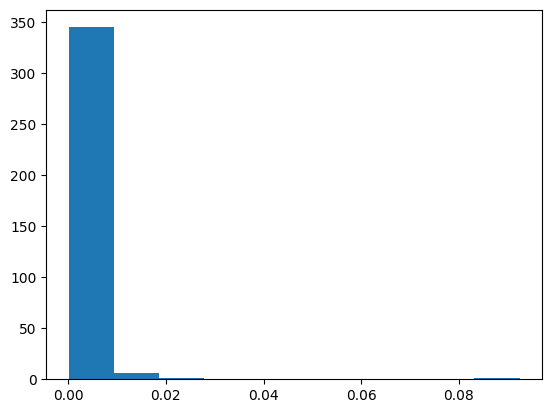

In [15]:
# threshold for a manageable number of features
plt.hist(clf.feature_importances_[clf.feature_importances_>0])
important_indices = np.where(clf.feature_importances_>0.005)[0]
print(important_indices)

In [16]:
# load entire dataset for these features. 
# note where the feature indices are split so we can load the correct ones straight from read_csv
n_date_features = 1156
X = np.concatenate([
    pd.read_csv("train_date.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices < n_date_features] + 1])).values,
    pd.read_csv("train_numeric.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices >= n_date_features] + 1 - 1156])).values
], axis=1)
y = pd.read_csv("train_numeric.csv", index_col=0, dtype=np.float32, usecols=[0,969]).values.ravel()

In [17]:
clf = XGBClassifier(
    max_depth=5,
    base_score=0.005
)

# 新版 sklearn 写法
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

# 保存每个样本的验证集预测概率
preds = np.ones(y.shape[0])

for i, (train, test) in enumerate(cv.split(X, y)):

    # 在当前 fold 的训练集上训练
    clf.fit(X[train], y[train])

    # 预测当前验证集属于 Response=1 的概率
    preds[test] = clf.predict_proba(X[test])[:, 1]

    # 计算当前 fold 的 ROC-AUC
    print(
        "fold {}, ROC AUC: {:.3f}".format(
            i,
            roc_auc_score(y[test], preds[test])
        )
    )

# 计算全部 OOF 预测的 ROC-AUC
print("Overall ROC AUC:", roc_auc_score(y, preds))

fold 0, ROC AUC: 0.710
fold 1, ROC AUC: 0.670
fold 2, ROC AUC: 0.695
Overall ROC AUC: 0.6915197896237872


0.16354087594730693


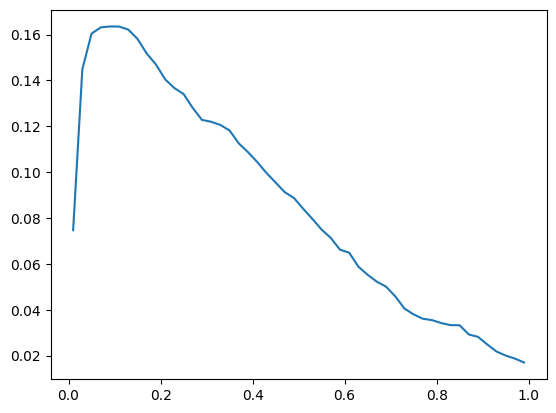

In [18]:
# pick the best threshold out-of-fold
thresholds = np.linspace(0.01, 0.99, 50)
mcc = np.array([matthews_corrcoef(y, preds>thr) for thr in thresholds])
plt.plot(thresholds, mcc)
best_threshold = thresholds[mcc.argmax()]
print(mcc.max())

In [19]:
# load test data
X = np.concatenate([
    pd.read_csv("test_date.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices<1156]+1])).values,
    pd.read_csv("test_numeric.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices>=1156] +1 - 1156])).values
], axis=1)

In [20]:
# generate predictions at the chosen threshold
preds = (clf.predict_proba(X)[:,1] > best_threshold).astype(np.int8)

In [21]:
# and submit
sub = pd.read_csv("sample_submission.csv", index_col=0)
sub["Response"] = preds
sub.to_csv("submission.csv.gz", compression="gzip")